In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate, Activation # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler  # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19


2025-11-16 20:16:46.759934: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-16 20:16:46.857378: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-16 20:16:46.905029: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-16 20:16:46.918390: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-16 20:16:46.985516: I tensorflow/core/platform/cpu_feature_guar

In [2]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [64]:
def mostrar_resultados2(
    X, y, y_pred, n=5, cmap='viridis',
    titulo_general="Comparación de Resultados",
    xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):

    n = min(n, len(X))

    # Tamaño de la figura (ajustado para evitar solapamientos)
    fig, axs = plt.subplots(n, 3, figsize=(14, 4.2 * n))

    # Espacio ajustado para evitar traslapes
    fig.subplots_adjust(
        top=0.93,       # espacio superior
        bottom=0.05,
        left=0.05,
        right=0.80,
        hspace=0.35,    # espacio vertical entre filas
        wspace=0     # espacio horizontal entre columnas
    )

    fig.suptitle(titulo_general, fontsize=18)

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}', fontsize=11)
        axs[i, 0].set_xlabel(xlabel, fontsize=10)
        axs[i, 0].set_ylabel(ylabel, fontsize=10)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}', fontsize=11)
        axs[i, 1].set_xlabel(xlabel, fontsize=10)
        axs[i, 1].set_ylabel(ylabel, fontsize=10)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}', fontsize=11)
        axs[i, 2].set_xlabel(xlabel, fontsize=10)
        axs[i, 2].set_ylabel(ylabel, fontsize=10)

    plt.show()

In [3]:
# Directorio con imagenes en tamaño original y  tamaño reducido
d_reducida = '/home/jhon/bandas/banda13/ene_oct_10m_reducida'

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas
# Normalización
all_pixels = np.concatenate([img.flatten() for img in images])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images = [(img - global_min) / (global_max - global_min + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

Procesando 7250 imágenes
Forma de X: (7249, 480, 480, 1)
Forma de y: (7249, 480, 480, 1)


In [9]:
from tensorflow.keras import Input, Model, layers

# Semilla
semilla = 42
tf.random.set_seed(semilla)



# =======================================
# 1. CAPA PARA REPLICAR 1 CANAL → 3 CANALES
# =======================================
replicate_layer = layers.Conv2D(
    filters=3,              # output channels
    kernel_size=1,          # 1x1 convolution
    use_bias=False,         # no bias needed
    trainable=False,        # freeze the layer
    name="replicate_layer"
)

replicate_layer.build(input_shape=(None, 480, 480, 1))

# Set weights como en tu configuración original
weights = tf.ones((1, 1, 1, 3))  # shape: (kernel_h, kernel_w, in_channels, out_channels)
replicate_layer.set_weights([weights])

# =======================================
# 2. CARGAR VGG19 Y EXTRAER PESOS
# =======================================
vgg = VGG19(weights='imagenet', include_top=False, input_shape=(480, 480, 3))

# block1_conv1  → index 1
vgg_w0, vgg_b0 = vgg.layers[1].get_weights()   # (3,3,3,64)


# =======================================
# 3. AJUSTAR PESOS PARA TUS CAPAS
# =======================================

# ---- Para la capa 3×3 (x1_3) ----
# De VGG (64 filtros) → 16 filtros
vgg_w0_16 = vgg_w0[:, :, :, :16]
vgg_b0_16 = vgg_b0[:16]

# =======================================
# 4. CONSTRUIR TU MODELO PERSONALIZADO
# =======================================
# Entrada original (1 canal)
inputs_raw = Input(shape=(480, 480, 1))

# Convertir 1 canal → 3 canales
inputs = replicate_layer(inputs_raw)

# === Bloque 1 ===
x1_3 = Conv2D(16, (3, 3), padding='same', activation='relu', name="x1_3")(inputs)
x1_5 = Conv2D(16, (5, 5), padding='same', activation='relu', name="x1_5")(inputs)

res1 = Concatenate()([x1_3, x1_5])

# === Bloque 2 ===
x2_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res1)
x2_5 = Conv2D(16, (5, 5), padding='same', activation='relu')(res1)

res2 = Concatenate()([x2_3, x2_5])
res2 = res2 + res1
res2 = Activation('relu')(res2)

# === Bloque 3 ===
x3_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res2)
x3_5 = Conv2D(16, (5, 5), padding='same', activation='relu')(res2)

res3 = Concatenate()([x3_3, x3_5])
res3 = res3 + res2
res3 = Activation('relu')(res3)

# === Bloque 4 ===
x4_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res3)
x4_5 = Conv2D(16, (5, 5), padding='same', activation='relu')(res3)

res_final = Concatenate()([x4_3, x4_5])
res_final = res_final + res3
res_final = Activation('relu')(res_final)

# === Salida ===
outputs = Conv2D(1, (1, 1), padding='same', activation='linear')(res_final)

# Crear modelo final
modelvgg_2 = Model(inputs_raw, outputs)

# =======================================
# 5. ASIGNAR PESOS VGG A TUS CAPAS
# =======================================
modelvgg_2.get_layer("x1_3").set_weights([vgg_w0_16, vgg_b0_16])

modelvgg_2.get_layer('replicate_layer').trainable = False
modelvgg_2.get_layer('x1_3').trainable = False

print("✔ Pesos de VGG asignados a x1_3 correctamente.")


✔ Pesos de VGG asignados a x1_3 correctamente.


In [10]:
# =====================================================
# PARÁMETROS DEL DECAY COSENOIDAL
# =====================================================
initial_lr = 1e-3       # Tasa de aprendizaje inicial
min_lr = 1e-5           # Tasa mínima al final del entrenamiento
epochs_total = 50       # Debe coincidir con el número de épocas del entrenamiento

# =====================================================
# FUNCIÓN COSINE DECAY (schedule)
# =====================================================
def cosine_decay_schedule(epoch, lr):
    """
    Calcula el decaimiento cosenoidal:
    lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + cos(pi * epoch / total_epochs))
    """
    cosine_decay = 0.5 * (1 + np.cos(np.pi * epoch / epochs_total))
    new_lr = min_lr + (initial_lr - min_lr) * cosine_decay
    return new_lr

# Crear callback de tasa de aprendizaje
lr_scheduler = LearningRateScheduler(cosine_decay_schedule, verbose=1)


optimizer = Adam(learning_rate=initial_lr)

modelvgg_2.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

print("Resumen del modelo:")
modelvgg_2.summary()

# =====================================================
# CALLBACKS
# =====================================================
checkpoint = ModelCheckpoint(
    filepath="modelovgg_2_best.h5",
    monitor="val_loss",  # Monitoreamos validación, no entrenamiento
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# =====================================================
# DIVISIÓN CRONOLÓGICA DE DATOS (SERIE DE TIEMPO)
# =====================================================
porc_validacion = 0.2
split_index = int(len(X) * (1 - porc_validacion))

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print(f"Tamaño entrenamiento: {len(X_train)} muestras")
print(f"Tamaño validación: {len(X_val)} muestras")

# Entrenamiento
print("Iniciando entrenamiento")
historyvgg_2 = modelvgg_2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=4,
    callbacks=[early_stop, checkpoint, lr_scheduler],
    verbose=1
)

print("¡Entrenamiento completado!")
print(f"Pérdida final: {historyvgg_2.history['loss'][-1]:.4f}")

Resumen del modelo:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 480, 480,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ replicate_layer     │ (None, 480, 480,  │          3 │ input_layer_8[0]… │
│ (Conv2D)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x1_3 (Conv2D)       │ (None, 480, 480,  │        448 │ replicate_layer[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x1_5 (Conv2D)       │ (None, 480, 480,  │      1,216 │ replicate_layer[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 480, 480,  │          0 │ x1_3[0][0],       │
│ (Concatenate)       │ 32)               │            │ x1_5[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 480, 480,  │      4,624 │ concatenate_10[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 480, 480,  │     12,816 │ concatenate_10[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 480, 480,  │          0 │ conv2d_16[0][0],  │
│ (Concatenate)       │ 32)               │            │ conv2d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 480, 480,  │          0 │ concatenate_11[0… │
│                     │ 32)               │            │ concatenate_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 480, 480,  │          0 │ add_7[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 480, 480,  │      4,624 │ activation_6[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 480, 480,  │     12,816 │ activation_6[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 480, 480,  │          0 │ conv2d_18[0][0],  │
│ (Concatenate)       │ 32)               │            │ conv2d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 480, 480,  │          0 │ concatenate_12[0… │
│                     │ 32)               │            │ activation_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 480, 480,  │          0 │ add_8[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 480, 480,  │      4,624 │ activation_7[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 480, 480,  │     12,816 │ activation_7[0][

 Total params: 54,020 (211.02 KB)

 Trainable params: 53,569 (209.25 KB)

...

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 66s 46ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16.1476 - root_mean_squared_error: 0.0738 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 19.8399 - val_root_mean_squared_error: 0.0832 - learning_rate: 7.1228e-05

Epoch 44: LearningRateScheduler setting learning rate to 5.711060902932042e-05.
Epoch 44/50
1449/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16.0652 - root_mean_squared_error: 0.0737
Epoch 44: val_loss improved from 0.00692 to 0.00692, saving model to modelovgg_2_best.h5


1450/1450 ━━━━━━━━━━━━━━━━━━━━ 66s 46ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16.1397 - root_mean_squared_error: 0.0737 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 19.6164 - val_root_mean_squared_error: 0.0832 - learning_rate: 5.7111e-05

Epoch 45: LearningRateScheduler setting learning rate to 4.4760639485315584e-05.
Epoch 45/50
1449/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16.0567 - root_mean_squared_error: 0.0737
Epoch 45: val_loss did not improve from 0.00692
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 66s 45ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16.1327 - root_mean_squared_error: 0.0737 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 19.4237 - val_root_mean_squared_error: 0.0832 - learning_rate: 4.4761e-05

Epoch 46: LearningRateScheduler setting learning rate to 3.4227024433899005e-05.
Epoch 46/50
1449/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 66s 45ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16.1130 - root_mean_squared_error: 0.0737 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 19.4404 - val_root_mean_squared_error: 0.0832 - learning_rate: 1.8768e-05

Epoch 49: LearningRateScheduler setting learning rate to 1.3903222849333507e-05.
Epoch 49/50
1449/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16.0293 - root_mean_squared_error: 0.0737
Epoch 49: val_loss improved from 0.00692 to 0.00691, saving model to modelovgg_2_best.h5


1450/1450 ━━━━━━━━━━━━━━━━━━━━ 66s 46ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16.1096 - root_mean_squared_error: 0.0737 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 19.5076 - val_root_mean_squared_error: 0.0831 - learning_rate: 1.3903e-05

Epoch 50: LearningRateScheduler setting learning rate to 1.0976769428005579e-05.
Epoch 50/50
1449/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16.0276 - root_mean_squared_error: 0.0737
Epoch 50: val_loss improved from 0.00691 to 0.00691, saving model to modelovgg_2_best.h5


1450/1450 ━━━━━━━━━━━━━━━━━━━━ 66s 45ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16.1079 - root_mean_squared_error: 0.0737 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 19.5396 - val_root_mean_squared_error: 0.0831 - learning_rate: 1.0977e-05
Restoring model weights from the end of the best epoch: 50.
¡Entrenamiento completado!
Pérdida final: 0.0054


RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0054, RMSE final: 0.0737, MAPE final: 16.1079
Validación    - Loss final: 0.0069, RMSE final: 0.0831, MAPE final: 19.5396


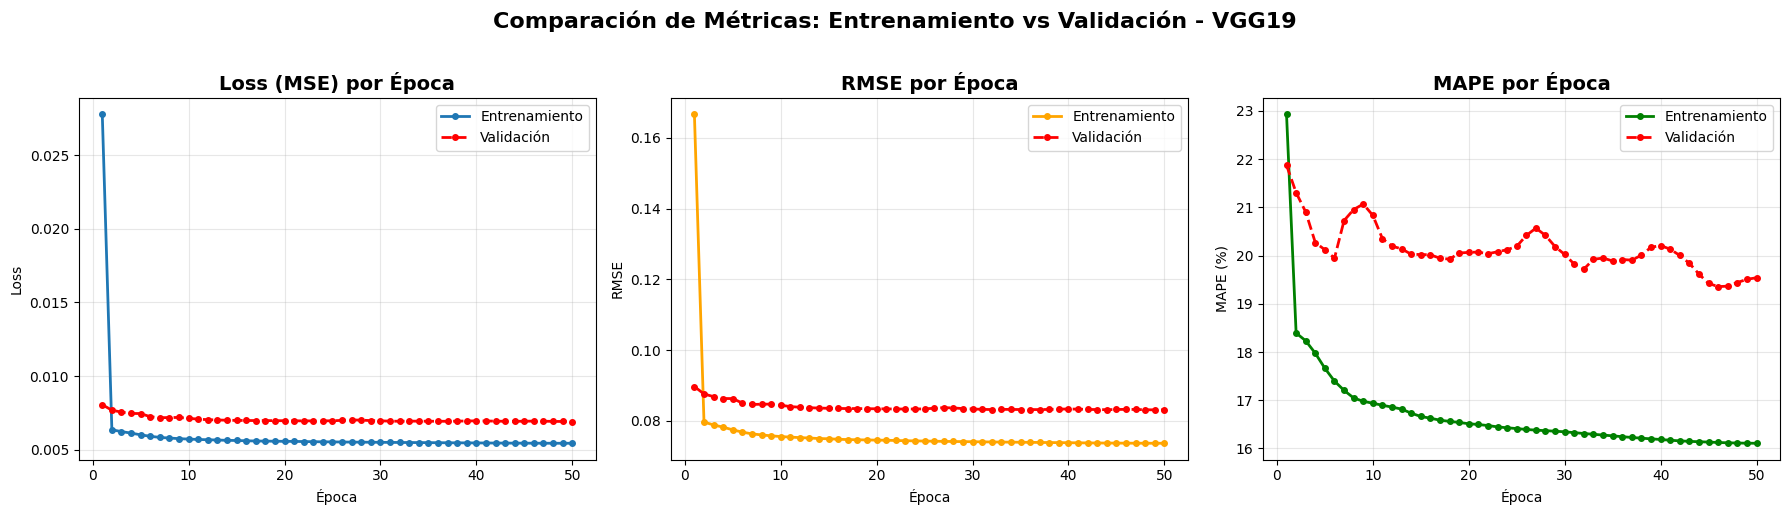

In [11]:
import matplotlib.pyplot as plt

# Extraer métricas del historial (entrenamiento y validación)
loss = historyvgg_2.history['loss']
val_loss = historyvgg_2.history['val_loss']

rmse = historyvgg_2.history['root_mean_squared_error']
val_rmse = historyvgg_2.history['val_root_mean_squared_error']
mape = historyvgg_2.history['mean_absolute_percentage_error']
val_mape = historyvgg_2.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - VGG19',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = modelvgg_2.evaluate(X_train, y_train, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

182/182 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16.1068 - root_mean_squared_error: 0.0737
Pérdida (MSE): 0.0054
RMSE: 0.0737
MAPE: 16.1068


In [13]:
# Obtener las métricas del modelo en el conjunto de validation
loss, rmse, mape = modelvgg_2.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - loss: 0.0069 - mean_absolute_percentage_error: 19.5380 - root_mean_squared_error: 0.0831
Pérdida (MSE): 0.0069
RMSE: 0.0831
MAPE: 19.5380


Visualización de imagenes

182/182 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step


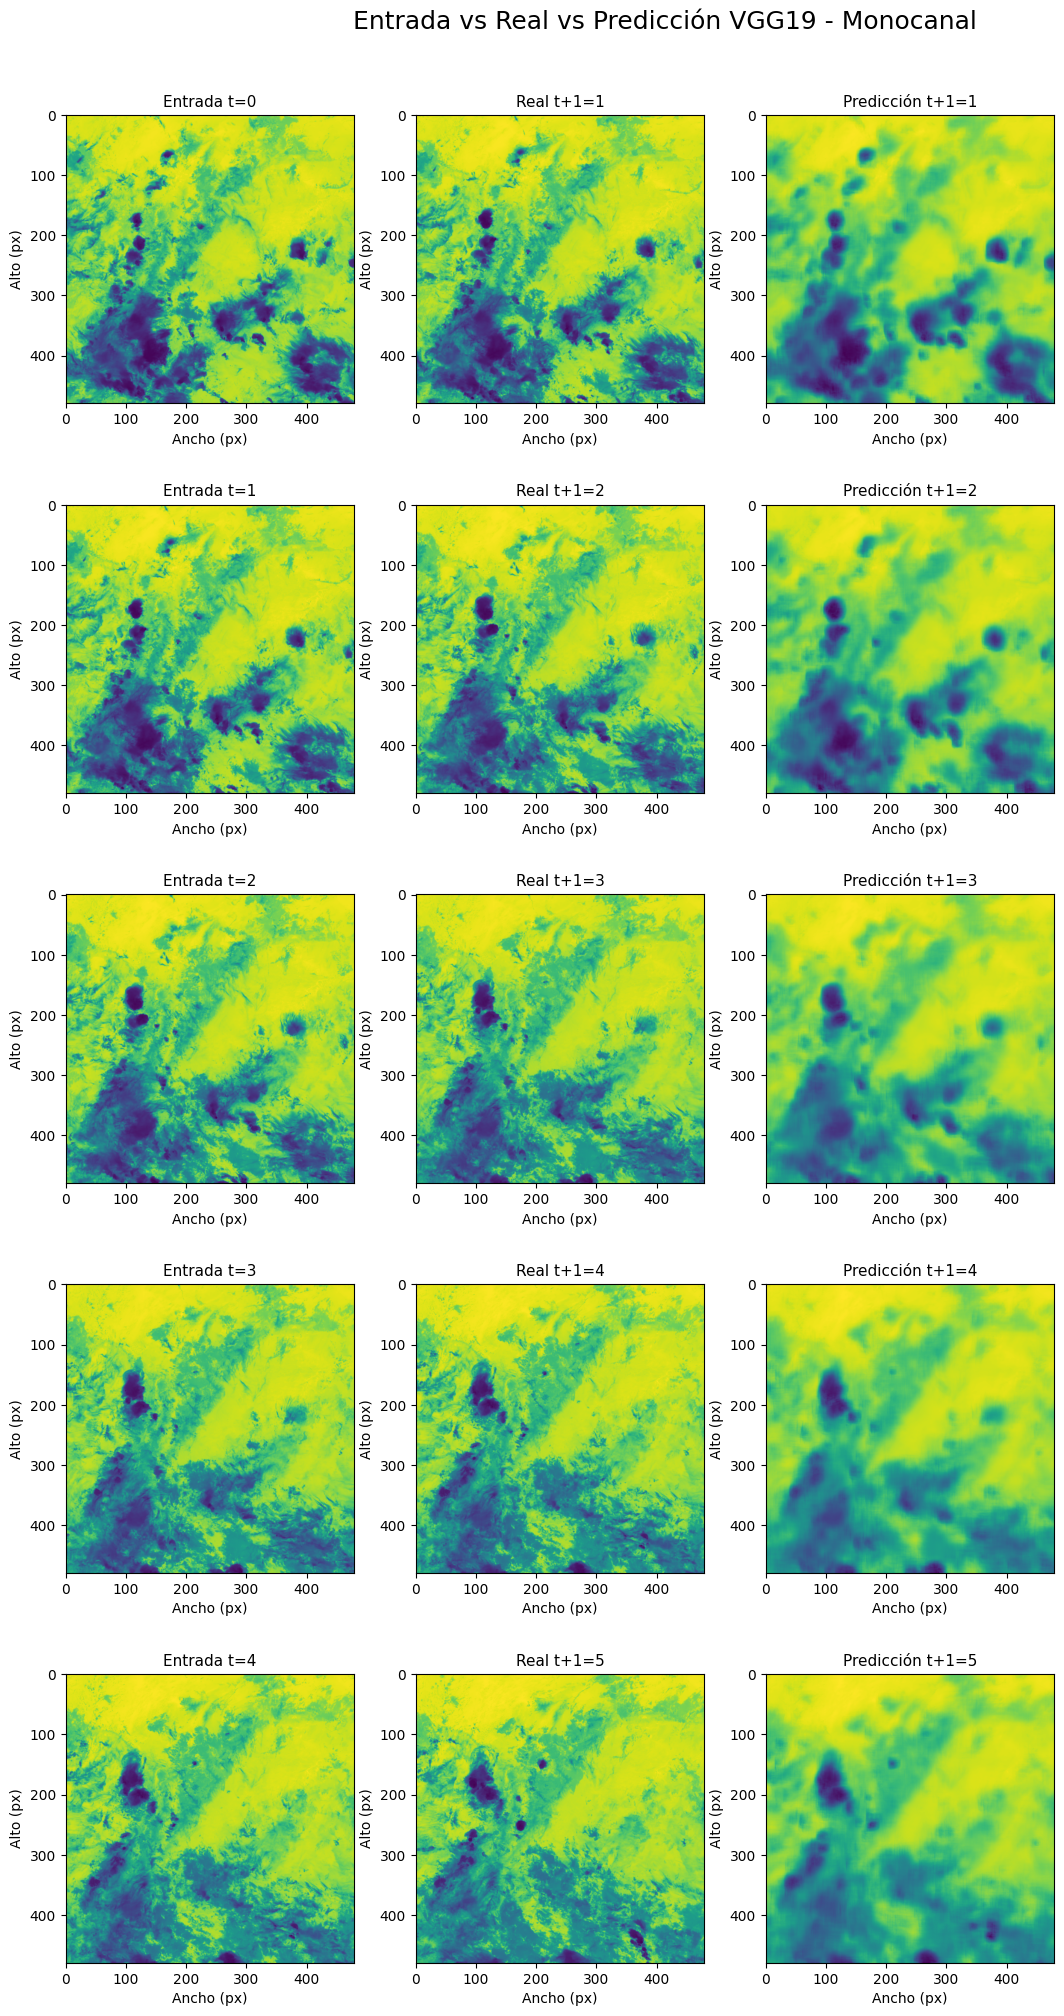

In [48]:
y_vgg_2 = modelvgg_2.predict(X_train)  # Genera las predicciones
mostrar_resultados2(
    X_train, y_train, y_vgg_2, n=5,
    titulo_general="Entrada vs Real vs Predicción VGG19 - Monocanal",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

prueba

In [49]:
# Directorio original y reducido para validación
d_mar_2s_red = '/home/jhon/bandas/banda13/nov_dic_2m_red'

# Llamar a la función para redimensionar imágenes

# Cargar imágenes de validación
file_list_test = sorted([f for f in os.listdir(d_mar_2s_red) if f.endswith('.npy')])
print(f"Procesando {len(file_list_test)} imágenes para validación")

images_test = [np.load(os.path.join(d_mar_2s_red, f)) for f in file_list_test]

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images_test])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images_test = [(img - global_min) / (global_max - global_min + 1e-8) for img in images_test]
images_test = [np.clip(img, 0, 1) for img in images_test]


X_test = np.array(images_test[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_test = np.array(images_test[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_test.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_test.shape}")  # Imprime la forma del array de salida


Procesando 1447 imágenes para validación
Forma de X: (1446, 480, 480, 1)
Forma de y: (1446, 480, 480, 1)


Metricas de testeo

In [50]:
# Obtener las métricas del modelo en el conjunto de test
loss, rmse, mape = modelvgg_2.evaluate(X_test, y_test, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0066 - mean_absolute_percentage_error: 19.2450 - root_mean_squared_error: 0.0813
Pérdida (MSE): 0.0066
RMSE: 0.0813
MAPE: 19.2450


46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step


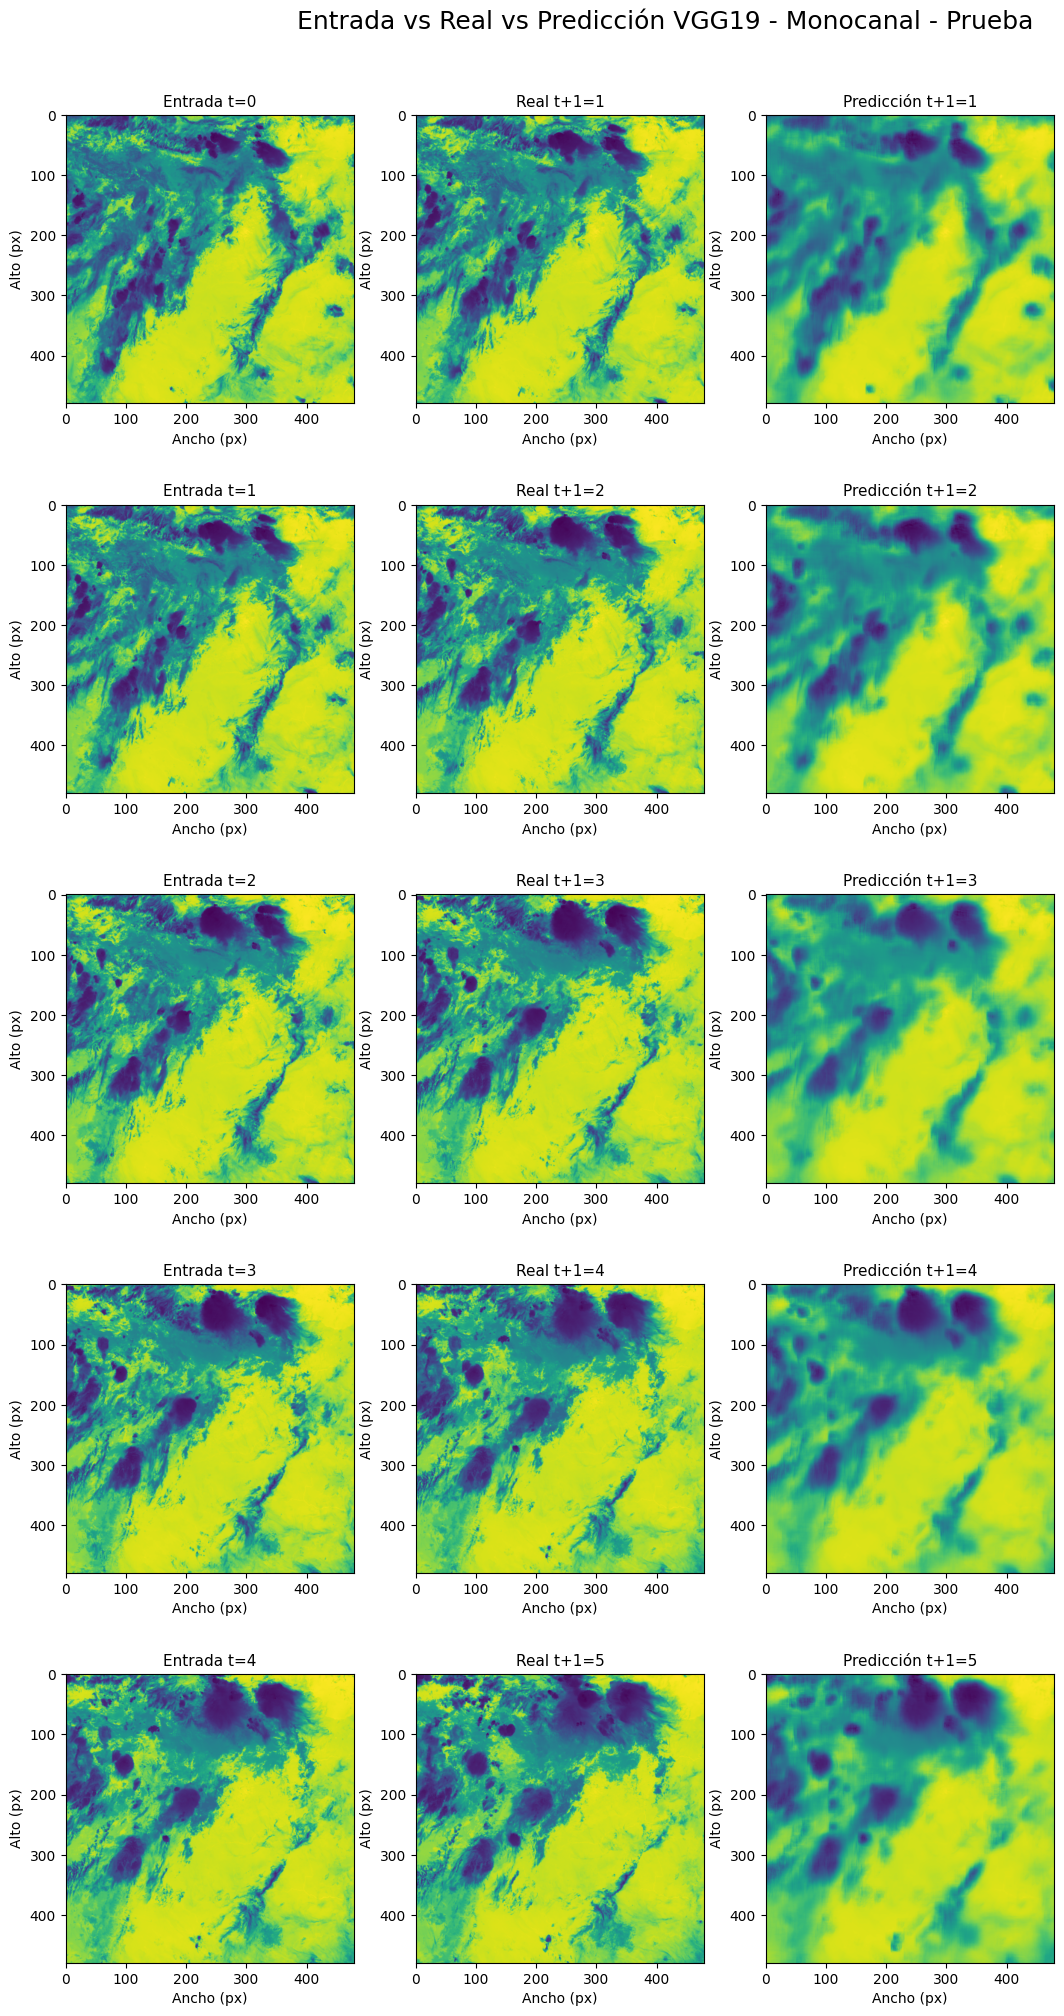

In [63]:
y_vgg_2_test = modelvgg_2.predict(X_test)  # Genera las predicciones
mostrar_resultados2(
    X_test, y_test, y_vgg_2_test, n=5,
    titulo_general="Entrada vs Real vs Predicción VGG19 - Monocanal - Prueba",
    xlabel="Ancho (px)", ylabel="Alto (px)"
    )

46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step


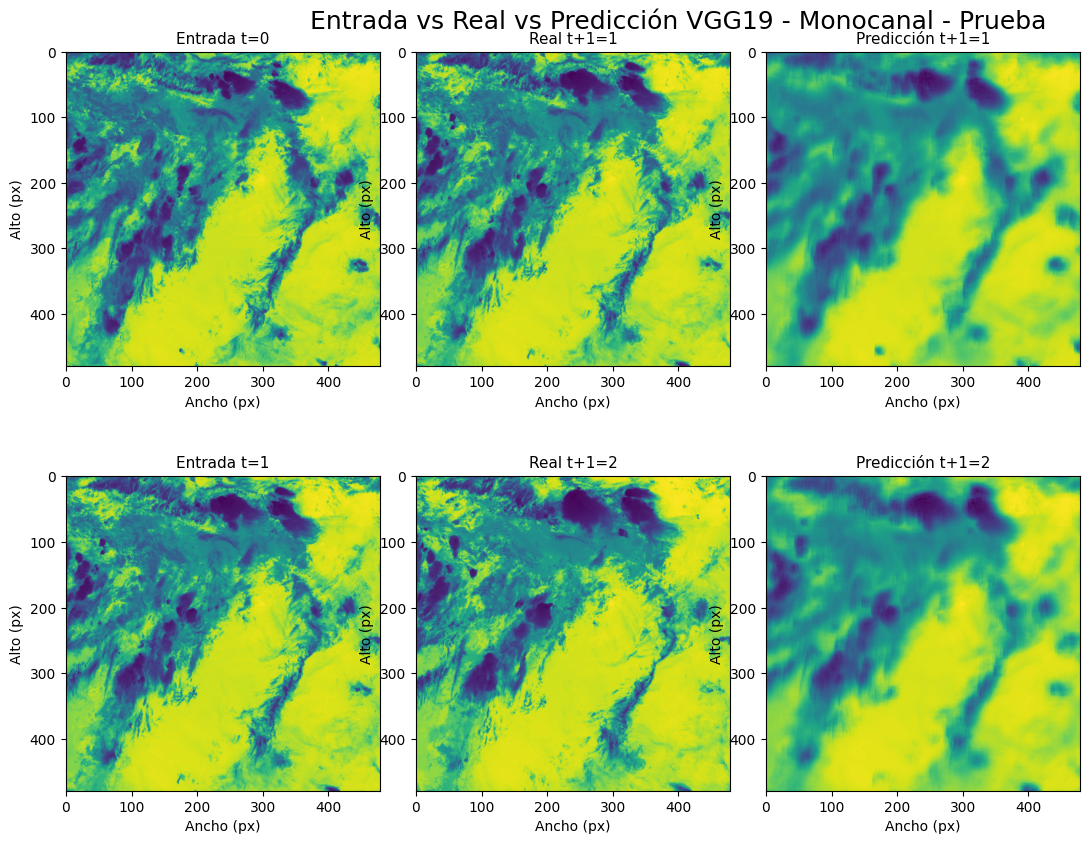

In [57]:
y_vgg_2_test = modelvgg_2.predict(X_test)  # Genera las predicciones
mostrar_resultados2(
    X_test, y_test, y_vgg_2_test, n=2,
    titulo_general="Entrada vs Real vs Predicción VGG19 - Monocanal - Prueba",
    xlabel="Ancho (px)", ylabel="Alto (px)"
    )